# Lead Priority — EDA, Feature Engineering & Modelling

Bu notebook **keşif (EDA)**, **feature engineering** ve **deney karşılaştırmalarını** içerir.
Servis edilebilir kod (`src/lead_priority/`) ayrı ve production kalitesindedir; burada onu
yeniden yazmak yerine *kullanarak* sonuçları görselleştiriyoruz.

İçerik:
1. Tabular veriyi yükle + EDA (dönüşüm oranı, sınıf dengesizliği, eksik veri, kaynak bazında dönüşüm)
2. Feature engineering örneği
3. Lead scoring: Logistic Regression (baseline) vs. LightGBM (kalibre)
4. Gain / Lift chart ve calibration
5. Sentiment / niyet sınıflandırması (TR + EN)
6. Birleşik öncelik skoru örneği

> Çalıştırmadan önce: `pip install -r requirements.txt -r requirements-notebook.txt && pip install -e .`

In [1]:
import sys
from pathlib import Path

# src/ layout: make the package importable from the notebook.
SRC = Path.cwd().parent / "src"
if SRC.is_dir() and str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lead_priority.config import TARGET_COLUMN, LEAKY_COLUMNS
from lead_priority.data.loaders import load_raw_leads

pd.set_option("display.max_columns", 60)

df = load_raw_leads()
print(df.shape)
df.head(3)

(9240, 37)


,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,How did you hear about X Education,What is your current occupation,What matters most to you in choosing a course,Search,Magazine,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Lead Quality,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,NaN,NaN,NaN,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Interested in other courses,Low in Relevance,No,No,NaN,NaN,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,India,NaN,NaN,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,NaN,No,No,NaN,NaN,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,India,Business Administration,NaN,Student,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened


## 1. EDA — dönüşüm oranı, sınıf dengesizliği, eksik veri

Genel dönüşüm (conversion) oranı: 0.385  (sınıf dengesizliği ~ 39%/61%)


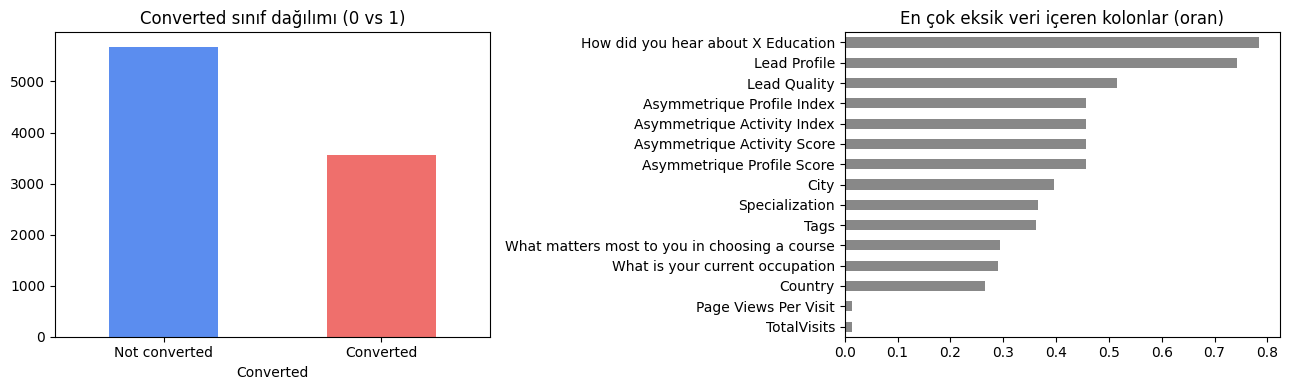

In [2]:
conv_rate = df[TARGET_COLUMN].mean()
print(f"Genel dönüşüm (conversion) oranı: {conv_rate:.3f}  (sınıf dengesizliği ~ {conv_rate:.0%}/{1-conv_rate:.0%})")

# Eksik veri paterni (en çok eksik olan 15 kolon)
missing = df.isna().mean().sort_values(ascending=False)
missing_top = missing[missing > 0].head(15)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df[TARGET_COLUMN].value_counts().plot(kind="bar", ax=axes[0], color=["#5b8def", "#ef6f6c"])
axes[0].set_title("Converted sınıf dağılımı (0 vs 1)")
axes[0].set_xticklabels(["Not converted", "Converted"], rotation=0)

missing_top.plot(kind="barh", ax=axes[1], color="#888")
axes[1].set_title("En çok eksik veri içeren kolonlar (oran)")
axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

                      mean  count
Lead Source                      
Welingak Website  0.985915    142
Reference         0.917603    534
Google            0.399930   2868
Organic Search    0.377816   1154
Direct Traffic    0.321667   2543
Olark Chat        0.255271   1755
Referral Sites    0.248000    125
Facebook          0.236364     55


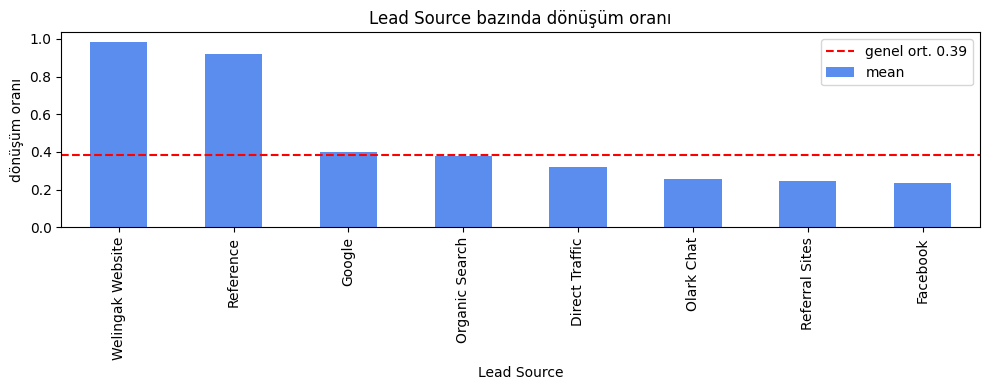

In [3]:
# Kaynak (Lead Source) bazında dönüşüm farkları — hacmi yüksek ilk 10 kaynak
src = (
    df.groupby("Lead Source")[TARGET_COLUMN]
    .agg(["mean", "count"])
    .query("count >= 50")
    .sort_values("mean", ascending=False)
)
print(src.head(10))

src["mean"].head(10).plot(kind="bar", figsize=(10, 4), color="#5b8def")
plt.axhline(conv_rate, color="red", ls="--", label=f"genel ort. {conv_rate:.2f}")
plt.ylabel("dönüşüm oranı"); plt.title("Lead Source bazında dönüşüm oranı"); plt.legend()
plt.tight_layout(); plt.show()

### Leakage (sızıntı) uyarısı

`Tags`, `Lead Quality`, `Last Notable Activity`, `Asymmetrique *` gibi kolonlar satış
süreci *sonrasında* dolar (ör. `Tags = "Closed by Horizzon"`). Bunlar `Converted` ile
neredeyse mükemmel korelasyon gösterir ama yeni bir lead skorlanırken **mevcut değildir**.
Bu yüzden `config.LEAKY_COLUMNS` içinde tutulur ve modelden düşürülür. Aşağıda farkı görelim.

In [4]:
if "Tags" in df.columns:
    tag_conv = df.groupby("Tags")[TARGET_COLUMN].agg(["mean", "count"]).query("count >= 50")
    print("Bazı 'Tags' değerleri neredeyse %100 / %0 dönüşüm => leakage:")
    print(tag_conv.sort_values("mean", ascending=False).head(5))
    print("...")
    print(tag_conv.sort_values("mean").head(3))
print("\nLeakage olarak işaretlenen kolonlar:", LEAKY_COLUMNS)

Bazı 'Tags' değerleri neredeyse %100 / %0 dönüşüm => leakage:
                                         mean  count
Tags                                                
Closed by Horizzon                   0.994413    358
Lost to EINS                         0.977143    175
Will revert after reading the email  0.968629   2072
Busy                                 0.564516    186
Graduation in progress               0.063063    111
...
                                 mean  count
Tags                                        
Already a student            0.006452    465
Not doing further education  0.006897    145
invalid number               0.012048     83

Leakage olarak işaretlenen kolonlar: ('Tags', 'Lead Quality', 'Lead Profile', 'Last Notable Activity', 'Asymmetrique Activity Index', 'Asymmetrique Profile Index', 'Asymmetrique Activity Score', 'Asymmetrique Profile Score')


## 2. Feature engineering

`add_engineered_features` üretilen feature'lar (gerekçeleriyle `src/.../features/engineering.py`):
`time_per_visit`, `total_page_views`, `log_time_spent`, `channel_diversity`,
`missing_field_count`, `do_not_contact`, `is_working_professional`, `is_high_intent_source`.

,count,mean,std,min,25%,50%,75%,max
time_per_visit,6914.0,202.357160,230.170304,0.0,43.578571,119.225000,280.229167,2059.000000
total_page_views,9103.0,13.513797,42.217059,0.0,1.000000,4.500000,16.000000,3025.000000
log_time_spent,9240.0,4.506633,2.742945,0.0,2.564949,5.517453,6.842683,7.728856
channel_diversity,9240.0,0.003139,0.075675,0.0,0.000000,0.000000,0.000000,5.000000
missing_field_count,9240.0,1.658225,1.705910,0.0,0.000000,2.000000,3.000000,7.000000
do_not_contact,9240.0,0.079654,0.270771,0.0,0.000000,0.000000,0.000000,1.000000
is_working_professional,9240.0,0.076407,0.265662,0.0,0.000000,0.000000,0.000000,1.000000
is_high_intent_source,9240.0,0.086688,0.281393,0.0,0.000000,0.000000,0.000000,1.000000


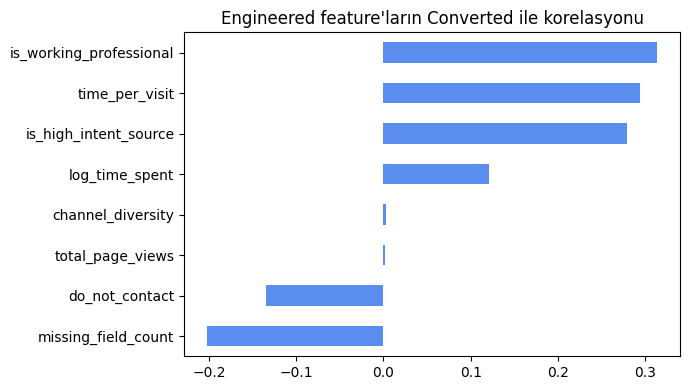

In [5]:
from lead_priority.features.engineering import add_engineered_features, ENGINEERED_NUMERIC_FEATURES

eng = add_engineered_features(df)
display(eng[list(ENGINEERED_NUMERIC_FEATURES)].describe().T)

# Engineered feature'ların hedefle ilişkisi (nokta-biserial ~ Pearson)
corr = eng[list(ENGINEERED_NUMERIC_FEATURES) + [TARGET_COLUMN]].corr()[TARGET_COLUMN].drop(TARGET_COLUMN)
corr.sort_values().plot(kind="barh", figsize=(7, 4), color="#5b8def")
plt.title("Engineered feature'ların Converted ile korelasyonu"); plt.tight_layout(); plt.show()

## 3-4. Lead scoring: baseline vs LightGBM + gain/lift + calibration

Eğitim mantığını tekrar yazmıyoruz; `train_lead_scoring_model` fonksiyonunu çağırıp
ürettiği metrikleri ve grafikleri gösteriyoruz (deterministik, seed sabit).

In [6]:
from lead_priority.scoring.train import train_lead_scoring_model

result = train_lead_scoring_model(quick=False, make_plots=True)

base = result.metrics["baseline_logreg"]
lgbm = result.metrics["lightgbm_calibrated"]
cmp = pd.DataFrame(
    {
        "LogReg (baseline)": {k: base[k] for k in ["roc_auc", "pr_auc", "brier_score", "f1"]},
        "LightGBM (calibrated)": {k: lgbm[k] for k in ["roc_auc", "pr_auc", "brier_score", "f1"]},
    }
).T
display(cmp.round(4))
print("Seçilen eşik (threshold):", round(result.threshold, 3))
print("Top %20 capture:", result.metrics["top_20pct_capture"])

,roc_auc,pr_auc,brier_score,f1
LogReg (baseline),0.8762,0.8114,0.1421,0.7534
LightGBM (calibrated),0.8896,0.8352,0.1287,0.7724


Seçilen eşik (threshold): 0.44
Top %20 capture: {'k': 0.2, 'n_top': 370, 'captured_conversions': 328, 'capture_rate': 0.4607, 'precision_in_top_k': 0.8865}


In [7]:
# Gain/lift tablosu ve üretilen grafikler
gain = pd.DataFrame(result.metrics["gain_lift_table"])
display(gain)

import matplotlib.image as mpimg
from lead_priority.config import REPORTS_DIR

for name in ["gain_chart.png", "calibration_curve.png", "confusion_matrix.png"]:
    p = REPORTS_DIR / name
    if p.exists():
        plt.figure(figsize=(5.5, 4.5)); plt.imshow(mpimg.imread(p)); plt.axis("off"); plt.show()

,decile,n,conversions,cumulative_conversions,cumulative_population_pct,cumulative_gain_pct,lift
0,1,185,170,170,0.1001,0.2388,2.3851
1,2,185,158,328,0.2002,0.4607,2.3009
2,3,185,122,450,0.3003,0.6320,2.1045
3,4,185,111,561,0.4004,0.7879,1.9677
4,5,185,68,629,0.5005,0.8834,1.7649
5,6,185,34,663,0.6006,0.9312,1.5503
6,7,185,27,690,0.7008,0.9691,1.3829
7,8,185,6,696,0.8009,0.9775,1.2206
8,9,184,11,707,0.9004,0.9930,1.1028
9,10,184,5,712,1.0000,1.0000,1.0000


/tmp/ipykernel_26451/3696550917.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.figure(figsize=(5.5, 4.5)); plt.imshow(mpimg.imread(p)); plt.axis("off"); plt.show()


## 5. Sentiment / niyet sınıflandırması (TR + EN) — fine-tuned transformer

4 sınıf: `positive_engagement`, `objection`, `disengaged`, `neutral`. Yaklaşım:
**`distilbert-base-multilingual-cased` fine-tune** (XLM-R'a `SENTIMENT_BASE_MODEL` ile
geçilebilir). Çok dilli sub-word sözlüğü TR+EN karışımını doğal olarak ele alır.
Etiket = üreten şablon sınıfı (Converted'tan **bağımsız** → leakage yok).

> Not: Aşağıda kaydedilmiş fine-tuned modeli yükleyip değerlendiriyoruz. Yeniden eğitmek
> için `from lead_priority.sentiment.train import train_sentiment_model; train_sentiment_model()`
> (CPU'da ~3 dk).

In [8]:
import json
from sklearn.metrics import ConfusionMatrixDisplay
from lead_priority.config import SENTIMENT_LABELS, SENTIMENT_METRICS_PATH, SENTIMENT_MODEL_DIR
from lead_priority.sentiment.model import SentimentClassifier

# Kaydedilmiş metrikler (train_all / train_sentiment_model çıktısı)
metrics = json.loads(SENTIMENT_METRICS_PATH.read_text())
print("model:", metrics["model"], "| accuracy:", round(metrics["accuracy"], 3),
      "| macro_f1:", round(metrics["macro_f1"], 3), "| dil dağılımı:", metrics["language_distribution"])

cm = np.array(metrics["confusion_matrix"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(SENTIMENT_LABELS))
disp.plot(xticks_rotation=45); plt.title("Sentiment confusion matrix (test)"); plt.tight_layout(); plt.show()

# Birkaç canlı tahmin (TR + EN karışık)
clf = SentimentClassifier.load()
for t in ["Müşteri çok ilgili, demo istedi.", "Too expensive, asked for a discount.",
          "Telefonu açmadı, ilgisiz.", "Broşürü gönderdim, dönecek."]:
    p = clf.predict(t)
    print(f"{p.label:>20}  (score={p.sentiment_score:.2f})  <- {t}")

/tmp/ipykernel_26451/3488534253.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  disp.plot(xticks_rotation=45); plt.title("Sentiment confusion matrix (test)"); plt.tight_layout(); plt.show()
The tokenizer you are loading from '/workspace/models/sentiment_transformer' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


model: distilbert-base-multilingual-cased | accuracy: 1.0 | macro_f1: 1.0 | dil dağılımı: {'tr': 768, 'en': 632}


 positive_engagement  (score=1.00)  <- Müşteri çok ilgili, demo istedi.
           objection  (score=0.55)  <- Too expensive, asked for a discount.
          disengaged  (score=0.10)  <- Telefonu açmadı, ilgisiz.
             neutral  (score=0.40)  <- Broşürü gönderdim, dönecek.


## 6. Birleşik öncelik skoru

`priority = w * P(convert) + (1-w) * sentiment_score`, ulaşılabilirlik kapısı ile.
Modelleri kaydedilmiş artefaktlardan yükleyip uçtan uca skorluyoruz.

In [9]:
from lead_priority.api.service import PriorityService

service = PriorityService.load()
examples = [
    ("Sıcak + olumlu", {"Lead Source": "Reference", "TotalVisits": 8, "Total Time Spent on Website": 1800,
                          "Page Views Per Visit": 4.0, "What is your current occupation": "Working Professional",
                          "Do Not Email": "No", "Do Not Call": "No"},
     "Müşteri çok ilgili, demo talep etti, hemen başlamak istiyor."),
    ("Soğuk + ilgisiz", {"Lead Source": "Olark Chat", "TotalVisits": 1, "Total Time Spent on Website": 20,
                          "Page Views Per Visit": 1.0, "Do Not Email": "No", "Do Not Call": "No"},
     "Telefonu açmadı, iki haftadır sessiz, ilgisiz."),
    ("İyi skor + itiraz", {"Lead Source": "Google", "TotalVisits": 5, "Total Time Spent on Website": 1200,
                            "Page Views Per Visit": 3.0, "Do Not Email": "No", "Do Not Call": "No"},
     "Fiyatı yüksek buldu ama ilgili, indirim olur mu diye sordu."),
]
rows = []
for name, feats, text in examples:
    r = service.score_lead(feats, text)
    rows.append({"senaryo": name, "P(convert)": r["conversion_probability"],
                 "sentiment": r["sentiment"]["label"], "priority": r["priority"]["priority_score"],
                 "tier": r["priority"]["tier"]})
pd.DataFrame(rows)

The tokenizer you are loading from '/workspace/models/sentiment_transformer' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


,senaryo,P(convert),sentiment,priority,tier
0,Sıcak + olumlu,0.8356,positive_engagement,0.8846,hot
1,Soğuk + ilgisiz,0.0291,disengaged,0.0507,cold
2,İyi skor + itiraz,0.2822,objection,0.3626,cooling


In [10]:
# Satış temsilcisinin sabah brief'i: "bugün ara" + "soğuyanlar"
brief = service.morning_brief(n_call=5, n_cooling=5)
print(f"Toplam {brief['total_leads']} lead\n")
print("== BUGÜN ARA ==")
display(pd.DataFrame(brief["call_today"])[["lead_id", "tier", "priority_score", "sentiment_label"]])
print("== SOĞUYOR (at-risk: değerliydi ama mesafelendi) ==")
display(pd.DataFrame(brief["cooling"])[["lead_id", "conversion_probability", "sentiment_label", "last_interaction"]])

Toplam 40 lead

== BUGÜN ARA ==


,lead_id,tier,priority_score,sentiment_label
0,lead-021,hot,0.9835,positive_engagement
1,lead-007,hot,0.9780,positive_engagement
2,lead-010,hot,0.8553,objection
3,lead-032,hot,0.8553,objection
4,lead-024,hot,0.8261,positive_engagement


== SOĞUYOR (at-risk: değerliydi ama mesafelendi) ==


,lead_id,conversion_probability,sentiment_label,last_interaction
0,lead-010,0.9862,objection,Said the timing is bad and the budget is alrea...
1,lead-032,0.9862,objection,"Bütçe onayı çıkmadı, fiyatı tekrar görüşmemiz ..."
2,lead-017,0.9517,disengaged,Unsubscribed from emails and did not pick up t...
3,lead-037,0.9394,disengaged,Unsubscribed from emails and did not pick up t...
4,lead-036,0.8989,disengaged,"Maile dönüş yapmadı, iki haftadır sessiz."
